To start we are going to create function to connect to db and view head of data after cleaning to verify it is working.

In [21]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Function to connect to SQLite database
def sql_connect():
    """Connect to SQLite combined_data.db"""
    return sqlite3.connect('combined_data.db')

#Connect and query combined data db to verify
with sql_connect() as conn:
    query = 'SELECT * FROM combined_table'
    df = pd.read_sql_query(query, conn)

# Display the first few rows of the DataFrame
print(df.head())

# Close the connection
conn.close()




   ages  list_price  num_reviews  piece_count  play_star_rating  \
0  6-12       29.99          2.0        277.0               4.0   
1  6-12       19.99          2.0        168.0               4.0   
2  6-12       12.99         11.0         74.0               4.3   
3   12+       99.99         23.0       1032.0               3.6   
4   12+       79.99         14.0        744.0               3.2   

                                           prod_desc  set_number  \
0  Catapult into action and take back the eggs fr...     75823.0   
1  Launch a flying attack and rescue the eggs fro...     75822.0   
2  Chase the piggy with lightning-fast Chuck and ...     75821.0   
3  Explore the architecture of the United States ...     21030.0   
4  Recreate the Solomon R. Guggenheim Museum® wit...     21035.0   

                                      prod_long_desc review_difficulty  \
0  Use the staircase catapult to launch Red into ...           Average   
1  Pilot Pig has taken off from Bird Isl

Setup additional functions to pull details on provided value for specific column names.

In [22]:
def get_data_by_review_difficulty(dataframe, target_value):
    """
    Pulls rows from a Pandas DataFrame where review_difficulty matches the target value.

    Args:
        dataframe (pd.DataFrame): The input DataFrame.
        target_value: The value to match in the review_difficulty column.

    Returns:
        pd.DataFrame: A new DataFrame containing only the rows that match the criteria.
    """
    filtered_df = dataframe.loc[dataframe['review_difficulty'] == target_value]
    return filtered_df

# Test the get data by set_number by pulling data for set number 75821.0
review_difficulty_easy = get_data_by_review_difficulty(df, 'Easy')
print("\nData where review difficulty is 'Easy':")
print(review_difficulty_easy)


Data where review difficulty is 'Easy':
     ages  list_price  num_reviews  piece_count  play_star_rating  \
1    6-12       19.99          2.0        168.0               4.0   
2    6-12       12.99         11.0         74.0               4.3   
12    12+       29.99          7.0        361.0               4.2   
15    10+       19.99          1.0        234.0               3.0   
20    10+        9.99          2.0        105.0               3.0   
..    ...         ...          ...          ...               ...   
677  7-14       29.99          6.0        341.0               4.4   
679  7-14       19.99          8.0        217.0               4.1   
680  7-14       19.99         18.0        233.0               4.6   
682  6-14        9.99         11.0        109.0               4.5   
683   10+        9.99          7.0        102.0               4.0   

                                             prod_desc  set_number  \
1    Launch a flying attack and rescue the eggs fro...     7

In [23]:
def get_data_by_theme(dataframe, target_value):
    """
    Pulls rows from a Pandas DataFrame where theme_name value matches the target value.

    Args:
        dataframe (pd.DataFrame): The input DataFrame.
        target_value: The value to match in the theme_name column.

    Returns:
        pd.DataFrame: A new DataFrame containing only the rows that match the criteria.
    """
    filtered_df = dataframe.loc[dataframe['theme_name'] == target_value]
    return filtered_df

# Test the get data by theme_name by pulling data for set theme Architecture
theme_architecture = get_data_by_theme(df, 'Architecture')
print("\nData where theme is 'Architecture':")
print(theme_architecture)


Data where theme is 'Architecture':
   ages  list_price  num_reviews  piece_count  play_star_rating  \
3   12+       99.99         23.0       1032.0               3.6   
4   12+       79.99         14.0        744.0               3.2   
7   12+       49.99         24.0        780.0               4.4   
10  12+       39.99         14.0        386.0               4.1   
11  12+       34.99         53.0        321.0               3.2   

                                            prod_desc  set_number  \
3   Explore the architecture of the United States ...     21030.0   
4   Recreate the Solomon R. Guggenheim Museum® wit...     21035.0   
7   Recreate Buckingham Palace with LEGO® Architec...     21029.0   
10    Experience the grandeur of the Arc de Triomphe!     21036.0   
11  Build your own LEGO® interpretation of the ico...     21019.0   

                                       prod_long_desc review_difficulty  \
3   Discover the architectural secrets of the icon...           Averag

In [24]:
def get_data_by_year_released(dataframe, target_value):
    """
    Pulls rows from a Pandas DataFrame where year_released value matches the target value.

    Args:
        dataframe (pd.DataFrame): The input DataFrame.
        target_value: The value to match in the year_released column.

    Returns:
        pd.DataFrame: A new DataFrame containing only the rows that match the criteria.
    """
    filtered_df = dataframe.loc[dataframe['year_released'] == target_value]
    return filtered_df

# Test the get data by year_released by pulling data for 2017
year_2017 = get_data_by_year_released(df, 2017)
print("\nData where year released is '2017':")
print(year_2017)


Data where year released is '2017':
     ages  list_price  num_reviews  piece_count  play_star_rating  \
4     12+       79.99         14.0        744.0               3.2   
9     12+       39.99         11.0        444.0               3.6   
10    12+       39.99         14.0        386.0               4.1   
12    12+       29.99          7.0        361.0               4.2   
13   7-12      159.99         63.0        847.0               3.8   
..    ...         ...          ...          ...               ...   
682  6-14        9.99         11.0        109.0               4.5   
683   10+        9.99          7.0        102.0               4.0   
684   10+        9.99          5.0         89.0               3.2   
685    5+        3.99         22.0          8.0               4.3   
686    5+        3.99         22.0          8.0               4.3   

                                             prod_desc  set_number  \
4    Recreate the Solomon R. Guggenheim Museum® wit...     21035

Setup Visualizations

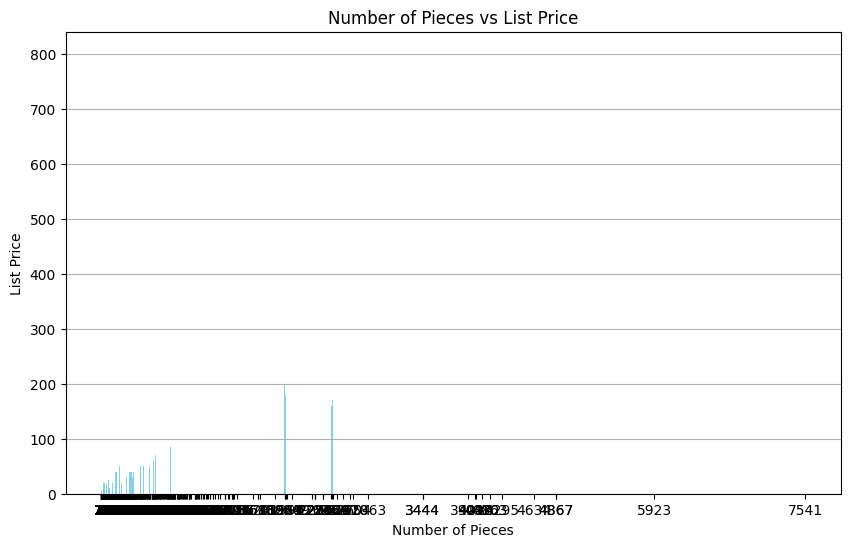

In [26]:
# Create a bar chart
plt.figure(figsize=(10, 6))
plt.bar(df['piece_count'], df['list_price'], color='skyblue')
plt.title('Number of Pieces vs List Price')
plt.xlabel('Number of Pieces')
plt.ylabel('List Price')
plt.xticks(df['piece_count'])
plt.grid(axis='y')

# Show the plot
plt.show()